# Statistic comparison

In [ ]:
import re
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

@dataclass
class ModelTrainingResult:
    model_name: str
    tumour_dice: float
    liver_dice: float
    mean_dice: float
    time: str
    epochs: int

def parse_time_to_hours(time_str: str) -> float:
    """Parses 'Xh Ym Zs' format into decimal hours."""
    match = re.match(r"(\d+)h\s*(\d+)m\s*(\d+)s", time_str)
    if match:
        h, m, s = map(int, match.groups())
        return h + m / 60.0 + s / 3600.0
    return 0.0

## pre stratification change
-----

### Validation stats

In [151]:
# Professional, colourblind-friendly palette
COLOR_TUMOUR = '#E63946'  # Red
COLOR_LIVER = '#457B9D'   # Blue
COLOR_MEAN = '#2A9D8F'    # Teal
COLOR_TIME = '#E9C46A'    # Sand/Yellow
FONT_COLOUR = '#F1F1F1'

def style_ax(ax):
    """Removes top/right spines and adds subtle gridlines for a clean academic look."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors='#555555', labelcolor=FONT_COLOUR)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#DDDDDD')
    ax.set_axisbelow(True)

def autolabel(rects, ax):
    """Annotates bars with their exact numerical values."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color=FONT_COLOUR)

def plot_results(model_list):
    models = [r.model_name for r in model_list]
    tumour_dice = [r.tumour_dice for r in model_list]
    liver_dice = [r.liver_dice for r in model_list]
    epochs = [r.epochs for r in model_list]

    times_hours = [parse_time_to_hours(r.time) for r in model_list]
    times_str = [r.time for r in model_list]


    x = np.arange(len(models))
    width = 0.25

    fig2, (ax2_top, ax2_bot) = plt.subplots(
        2, 1, figsize=(9, 8),
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.2},
        layout='constrained'  # <--- Add this
    )

    # --- Top Plot: Dice Scores ---
    rects2 = ax2_top.bar(x - width, liver_dice, width, label='Liver Dice', color=COLOR_LIVER, edgecolor='white', linewidth=1.2)
    rects1 = ax2_top.bar(x, tumour_dice, width, label='Tumour Dice', color=COLOR_TUMOUR, edgecolor='white', linewidth=1.2)

    ax2_top.set_ylabel('Dice Score', fontsize=11, fontweight='bold', color=FONT_COLOUR)
    ax2_top.set_title('Model Performance vs. Training Time', fontsize=13, fontweight='bold', pad=10, color=FONT_COLOUR)

    ax2_top.set_xticks(x, labels=models, fontsize=11, fontweight='bold', color=FONT_COLOUR)

    ax2_top.set_ylim(0, 1.15)
    ax2_top.legend(frameon=False, fontsize=10, loc='upper left', labelcolor=FONT_COLOUR)

    style_ax(ax2_top)
    autolabel(rects2, ax2_top)
    autolabel(rects1, ax2_top)

    # --- Bottom Plot: Training Time ---
    ax2_bot.bar(x, times_hours, width=0.5, color=COLOR_TIME, edgecolor='white', linewidth=1.2)
    ax2_bot.set_xticks(x, labels=[]) 
    ax2_bot.set_ylabel('Time (hours)', fontsize=11, fontweight='bold', color=FONT_COLOUR)
    ax2_bot.set_xticklabels([]) # Hide to avoid duplicating model names
    ax2_bot.set_ylim(0, max(times_hours) * 1.4)


    style_ax(ax2_bot)

    y_max = ax2_bot.get_ylim()[1]
    offset = y_max * 0.05  # 5% of the total Y-axis height

    for i, v in enumerate(times_hours):
        ax2_bot.text(i, v + offset, f"{v:.1f} h \n ({epochs[i]} epochs)\n{times_str[i]}", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color=FONT_COLOUR)

    return fig2

In [78]:
unet = ModelTrainingResult(
    model_name="ResUNet",
    tumour_dice=0.487682,
    liver_dice=0.859915,
    mean_dice=0.682258,
    time="3h 49m 48s",
    epochs=168
)

segresnet = ModelTrainingResult(
    model_name="SegResNet",
    tumour_dice=0.628851,
    liver_dice=0.933802,
    mean_dice=0.788257,
    time="8h 0m 37s",
    epochs=151
)

swinunetr = ModelTrainingResult(
    model_name="SwinUNETR",
    tumour_dice=0.538915,
    liver_dice=0.855036,
    mean_dice=0.704160,
    time="14h 17m 39s",
    epochs=123
)

pre_strat = [unet, segresnet, swinunetr]

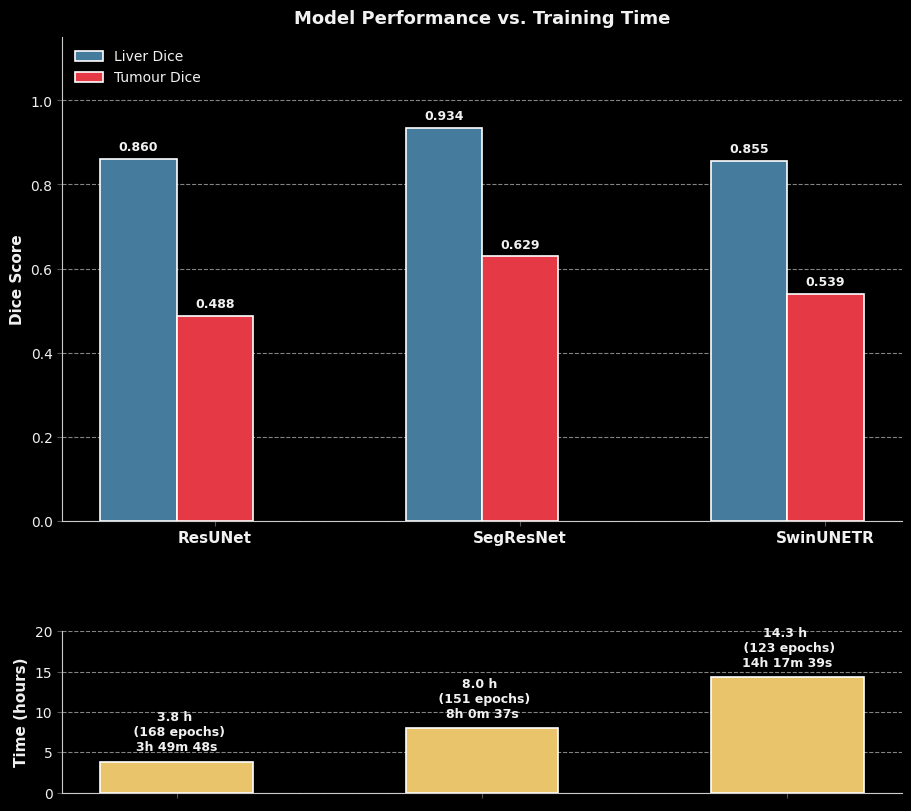

In [152]:
fig = plot_results(pre_strat)

### Test stats

In [131]:
raw_resunet_test = pd.read_csv('../files/server_logs/old_split/last_unet/validate/no-postprocess/reports/test_evaluation_results.csv')
raw_segresnet_test = pd.read_csv('../files/server_logs/old_split/last_segres/validate/no-post/reports/test_evaluation_results.csv')
# SwinUNETR missing

post_resunet_test = pd.read_csv('../files/server_logs/old_split/last_unet/validate/postprocess/reports/test_evaluation_results.csv')
post_segresnet_test = pd.read_csv('../files/server_logs/old_split/last_segres/validate/postprocess/reports/test_evaluation_results.csv')
# SwinUNETR missing

In [90]:
raw_resunet_test.describe()

,dice_liver,dice_tumour,hd95_liver_mm,hd95_tumour_mm
count,20.000000,15.000000,20.000000,15.000000
mean,0.662266,0.221476,222.718005,173.084694
std,0.221254,0.213805,67.103723,91.550235
min,0.007153,0.000000,73.396187,60.016663
25%,0.609795,0.029909,181.922104,128.939377
50%,0.740547,0.102968,221.047310,146.017120
75%,0.782994,0.405533,254.167213,182.122421
max,0.898121,0.615285,400.530884,358.587921


In [ ]:
# ==========================================
# THEME & STYLE CONSTANTS
# ==========================================
COLOR_TUMOUR = '#E63946'  # Red
COLOR_LIVER = '#457B9D'   # Blue
COLOR_OUTLIER = '#FF0000' # Bright red to highlight catastrophic failures
FONT_COLOUR = '#F1F1F1'   # Almost white (ideal for dark Jupyter themes)
GRID_COLOUR = '#DDDDDD'
MEAN_COLOUR = '#FFD700'   # Gold/Yellow to distinguish the mean from the quartiles

def style_ax(ax):
    """Removes top/right spines and adds subtle gridlines."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors=FONT_COLOUR)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color=GRID_COLOUR)
    ax.set_axisbelow(True)

def resolve_overlaps(positions, min_gap):
    """
    Adjusts a list of Y positions so they are at least min_gap apart.
    Processes from bottom to top, pushing higher labels up if they collide.
    """
    sorted_indices = sorted(range(len(positions)), key=lambda k: positions[k])
    adjusted = list(positions)
    for i in range(1, len(sorted_indices)):
        curr_idx = sorted_indices[i]
        prev_idx = sorted_indices[i-1]
        if adjusted[curr_idx] - adjusted[prev_idx] < min_gap:
            adjusted[curr_idx] = adjusted[prev_idx] + min_gap
    return adjusted

# ==========================================
# STATISTICAL BOXPLOTS (WITH SMART LABELS)
# ==========================================
def plot_test_boxplots(df: pd.DataFrame, model_name: str = "Model"):
    """
    Generates boxplots with overlaid strip plots (jitter). 
    Outliers are highlighted in red. Labels for Q1, Median, Q3, and Mean 
    are added to the right of each box. Overlapping labels are automatically 
    shifted apart and connected with a dotted line.
    """
    # Drop NaNs safely (happens when a structure is absent)
    d_liv = df['dice_liver'].dropna().values
    d_tum = df['dice_tumour'].dropna().values
    h_liv = df['hd95_liver_mm'].dropna().values
    h_tum = df['hd95_tumour_mm'].dropna().values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.3})

    def draw_metric_boxplot(ax, data_list, colors, title, ylabel, y_lim=None):
        # 1. Draw the boxplot
        bp = ax.boxplot(data_list, patch_artist=True, widths=0.5,
                        boxprops=dict(linewidth=1.5, edgecolor='white'),
                        whiskerprops=dict(linewidth=1.5, color='white', linestyle='--'),
                        capprops=dict(linewidth=1.5, color='white'),
                        medianprops=dict(linewidth=2, color=FONT_COLOUR),
                        flierprops=dict(marker='o', markerfacecolor=COLOR_OUTLIER, 
                                        markersize=8, markeredgecolor='white', linewidth=1.5))
        
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)

        # 2. Determine final Y-limits to calculate accurate min_gap
        if y_lim is not None:
            final_y_min, final_y_max = y_lim
        else:
            all_data = np.concatenate([d for d in data_list if len(d) > 0])
            max_val = np.nanmax(all_data) if len(all_data) > 0 else 1.0
            final_y_min = 0
            final_y_max = max_val * 1.35 if max_val > 0 else 1.0
            
        y_range = final_y_max - final_y_min
        min_gap = y_range * 0.04  # 4% of the total Y-axis height

        # 3. Overlay strip plot and add statistical labels
        for i, data in enumerate(data_list, 1):
            if len(data) == 0:
                continue  # Skip empty data to avoid errors

            # Jitter for all points
            x_jitter = np.random.normal(i, 0.06, size=len(data))
            ax.scatter(x_jitter, data, alpha=0.5, color='#333333', s=20, zorder=2, edgecolors='none')
            
            # Re-plot outliers in RED
            q1_val, q3_val = np.percentile(data, [25, 75])
            iqr = q3_val - q1_val
            upper_bound = q3_val + 1.5 * iqr
            outliers = data[data > upper_bound]
            if len(outliers) > 0:
                x_outliers = np.random.normal(i, 0.06, size=len(outliers))
                ax.scatter(x_outliers, outliers, color=COLOR_OUTLIER, s=60, zorder=5, 
                           edgecolors='white', linewidth=1.5)

            # --- STATISTICAL LABELS ---
            med_val = np.median(data)
            mean_val = np.mean(data)
            
            # Distinct white diamond marker for the mean
            ax.scatter(i, mean_val, marker='D', color='white', edgecolors=FONT_COLOUR, s=40, zorder=6)
            
            # Resolve overlapping labels dynamically
            raw_ys = [q3_val, med_val, q1_val, mean_val]
            adjusted_ys = resolve_overlaps(raw_ys, min_gap)
            
            labels_info = [
                {'y': adjusted_ys[0], 'orig_y': q3_val, 'text': f'Q3: {q3_val:.3f}', 'color': FONT_COLOUR},
                {'y': adjusted_ys[1], 'orig_y': med_val, 'text': f'Med: {med_val:.3f}', 'color': FONT_COLOUR},
                {'y': adjusted_ys[2], 'orig_y': q1_val, 'text': f'Q1: {q1_val:.3f}', 'color': FONT_COLOUR},
                {'y': adjusted_ys[3], 'orig_y': mean_val, 'text': f'Mean: {mean_val:.3f}', 'color': MEAN_COLOUR},
            ]
            
            label_x = i + 0.35
            for item in labels_info:
                ax.text(label_x, item['y'], item['text'], va='center', ha='left', 
                        color=item['color'], fontsize=9, 
                        fontweight='bold' if item['color'] == MEAN_COLOUR else 'normal')
                
                # Draw a faint dotted line if the label was shifted to avoid overlap
                if abs(item['y'] - item['orig_y']) > 1e-5:
                    ax.plot([i + 0.26, label_x - 0.02], [item['orig_y'], item['y']], 
                            color='#777777', linestyle=':', linewidth=1, alpha=0.8)

        # 4. Finalize axes
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10, color=FONT_COLOUR)
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', color=FONT_COLOUR)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Liver', 'Tumour'], fontsize=11, fontweight='bold', color=FONT_COLOUR)
        
        # Expanded X-limits to ensure the text labels on the right are not clipped
        ax.set_xlim(0.5, 3.2) 
        ax.set_ylim(final_y_min, final_y_max)
        
        style_ax(ax)

    # --- TOP PLOT: DICE SCORES ---
    draw_metric_boxplot(ax1, [d_liv, d_tum], [COLOR_LIVER, COLOR_TUMOUR],
                        f'{model_name} Test Set: Dice Score Distribution',
                        'Dice Similarity Coefficient', y_lim=[-0.05, 1.1])

    # --- BOTTOM PLOT: HAUSDORFF DISTANCE (HD95) ---
    draw_metric_boxplot(ax2, [h_liv, h_tum], [COLOR_LIVER, COLOR_TUMOUR],
                        f'{model_name} Test Set: Boundary Distance (HD95)',
                        '95th Percentile Hausdorff Distance (mm)')

    return fig

In [128]:
raw_resunet_test[raw_segresnet_test['dice_tumour'].isna()]

,case_name,dice_liver,dice_tumour,hd95_liver_mm,hd95_tumour_mm
4,volume-32.nii,0.898121,NaN,216.695740,NaN
6,volume-34.nii,0.530068,NaN,73.396187,NaN
10,volume-38.nii,0.778257,NaN,232.488708,NaN
13,volume-41.nii,0.742832,NaN,217.083511,NaN
18,volume-47.nii,0.708949,NaN,293.191071,NaN


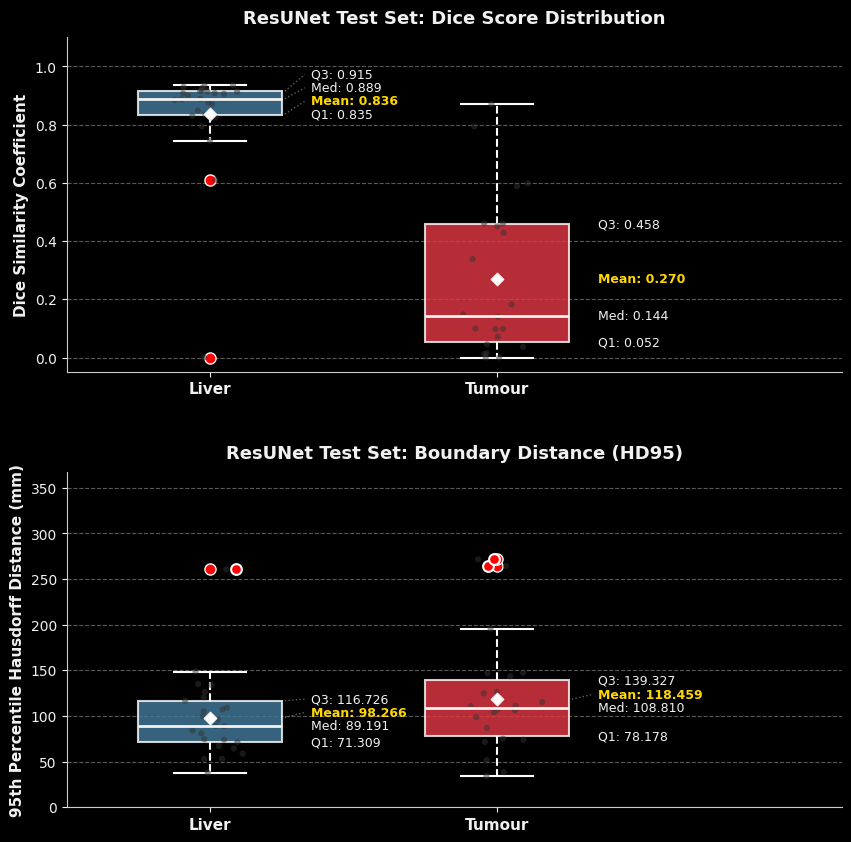

In [142]:
fig = plot_test_boxplots(raw_resunet_test, model_name="ResUNet")

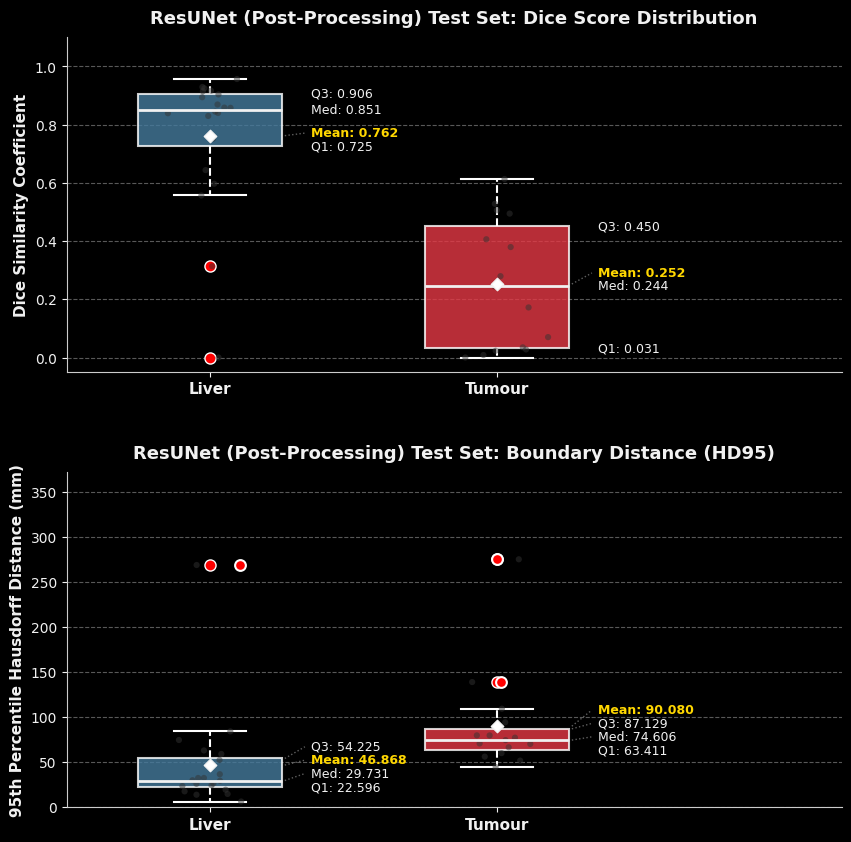

In [143]:
fig = plot_test_boxplots(post_resunet_test, model_name="ResUNet (Post-Processing)")

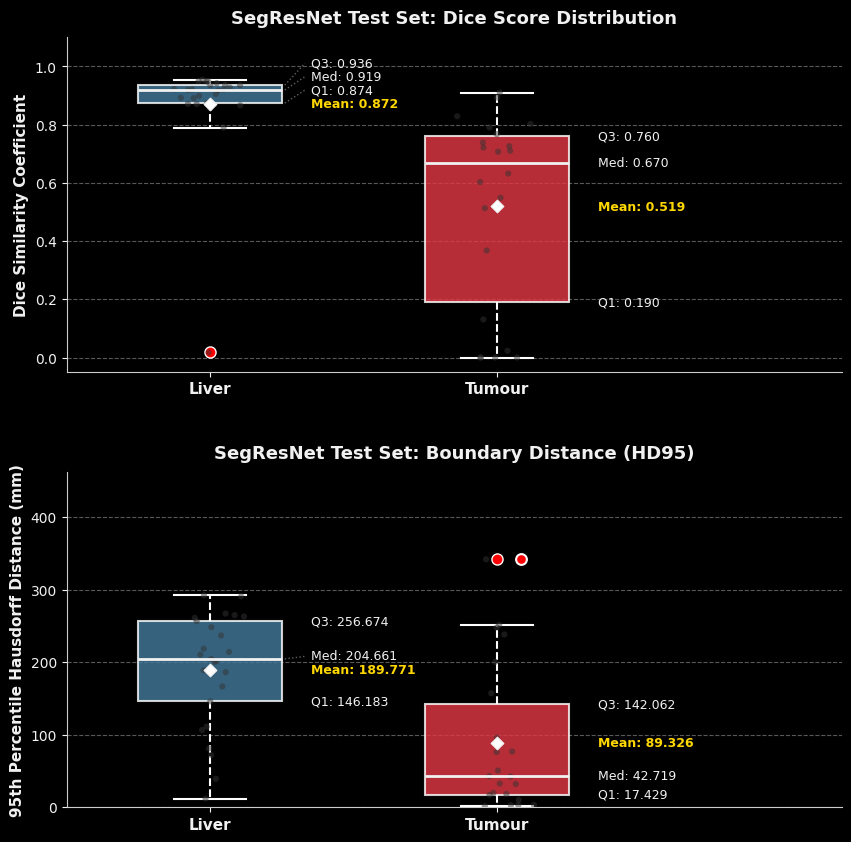

In [144]:
fig = plot_test_boxplots(raw_segresnet_test, model_name="SegResNet")

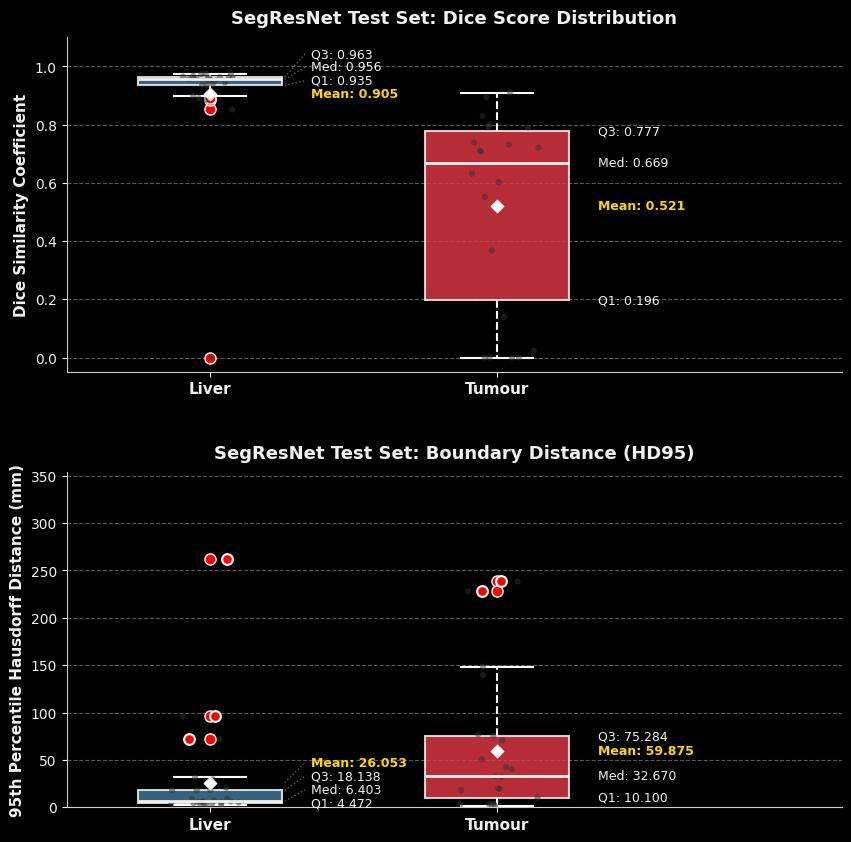

In [145]:
fig = plot_test_boxplots(post_segresnet_test, model_name="SegResNet")

In [118]:
# ==========================================
# 2. CONCEPTUAL SCHEMATIC (FOR THESIS TEXT)
# ==========================================
def plot_hd95_conceptual_schematic():
    """
    Generates a conceptual 2D diagram to include in the thesis text.
    It visually explains why a single missed slice causes a massive HD95 spike 
    but barely affects the 3D Dice score.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle("Conceptual Interpretation of HD95 vs. Dice", 
                 fontsize=14, fontweight='bold', color=FONT_COLOUR, y=0.95)

    for ax in axes:
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_facecolor('#1E1E1E') # Dark background for schematic

    # --- LEFT: Minor Boundary Jitter ---
    ax1 = axes[0]
    # Ground Truth (Blue)
    gt1 = Circle((5, 5), 3, fill=False, edgecolor=COLOR_LIVER, linewidth=3, label='Ground Truth')
    # Prediction (Red, slightly wobbly/offset)
    pred1 = Circle((5.2, 4.8), 3.1, fill=False, edgecolor=COLOR_TUMOUR, linewidth=2, linestyle='--', label='Prediction')
    
    ax1.add_patch(gt1)
    ax1.add_patch(pred1)
    ax1.set_title("Scenario A: Minor Boundary Jitter", fontsize=12, color=FONT_COLOUR, pad=10)
    ax1.text(5, 1.5, "Dice: High (e.g., 0.90)\nHD95: Low (e.g., 2.0 mm)", 
             ha='center', fontsize=11, color=FONT_COLOUR, fontweight='bold')
    ax1.text(5, -0.5, "Typical prediction noise.", ha='center', fontsize=10, style='italic', color='#AAAAAA')

    # --- RIGHT: Catastrophic Slice Failure ---
    ax2 = axes[1]
    # Ground Truth (Blue)
    gt2 = Circle((5, 5), 3, fill=False, edgecolor=COLOR_LIVER, linewidth=3)
    # Prediction (Red, completely misses a chunk/slice)
    # We simulate a missed slice by drawing a prediction that is shifted or missing a section
    pred2_arc = Arc((5, 5), 6, 6, angle=0, theta1=30, theta2=300,
                edgecolor=COLOR_TUMOUR, linewidth=2, linestyle='--')
    # Draw a "missed" region indicator
    missed_rect = Rectangle((6.5, 2), 2, 4, edgecolor=COLOR_OUTLIER, facecolor=COLOR_OUTLIER, alpha=0.3, linewidth=2)
    # Shade the missed wedge region inside the GT circle
    missed_wedge = Wedge((5, 5), 3, 300, 60, 
                        facecolor=COLOR_OUTLIER, alpha=0.35, edgecolor='none')

    ax2.add_patch(missed_wedge)
    ax2.add_patch(gt2)
    ax2.add_patch(pred2_arc)
    ax2.add_patch(missed_rect)
    
    ax2.set_title("Scenario B: Catastrophic Slice Failure", fontsize=12, color=FONT_COLOUR, pad=10)
    ax2.text(5, 1.5, "Dice: Moderate (e.g., 0.75)\nHD95: MASSIVE (e.g., 80.0 mm)", 
             ha='center', fontsize=11, color=FONT_COLOUR, fontweight='bold')
    ax2.text(5, -0.5, "A single missed slice destroys HD95,\nbut 3D volume overlap (Dice) remains okay.", 
             ha='center', fontsize=10, style='italic', color='#AAAAAA')

    # Legend
    legend_handles = [mpatches.Patch(color=COLOR_LIVER, label='Ground Truth'),
                      mpatches.Patch(color=COLOR_TUMOUR, label='Prediction'),
                      mpatches.Patch(color=COLOR_OUTLIER, alpha=0.5, label='Missed Region')]
    fig.legend(handles=legend_handles, loc='lower center', ncol=3, 
               frameon=False, fontsize=11, labelcolor=FONT_COLOUR, bbox_to_anchor=(0.5, 0.05))

    plt.tight_layout(rect=[0, 0.1, 1, 0.92])
    return fig

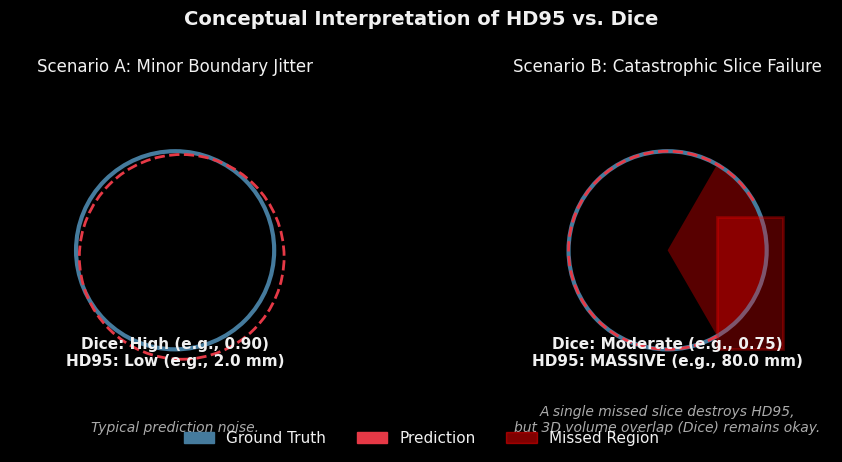

In [121]:
fig2 = plot_hd95_conceptual_schematic()

## Post stratification change
-----

In [80]:
unet = ModelTrainingResult(
    model_name="ResUNet",
    tumour_dice=0.260151,
    liver_dice=0.803238,
    mean_dice=0.553418,
    time="1h 38m 4s",
    epochs=138
)

segresnet = ModelTrainingResult(
    model_name="SegResNet",
    tumour_dice=0.418732,
    liver_dice=0.841984,
    mean_dice=0.647288,
    time="8h 59m 30s",
    epochs=200
)

swinunetr = ModelTrainingResult(
    model_name="SwinUNETR",
    tumour_dice=0.434832,
    liver_dice=0.807407,
    mean_dice=0.636023,
    time="48h 55m 59s",
    epochs=200
)

post_strat = [unet, segresnet, swinunetr]

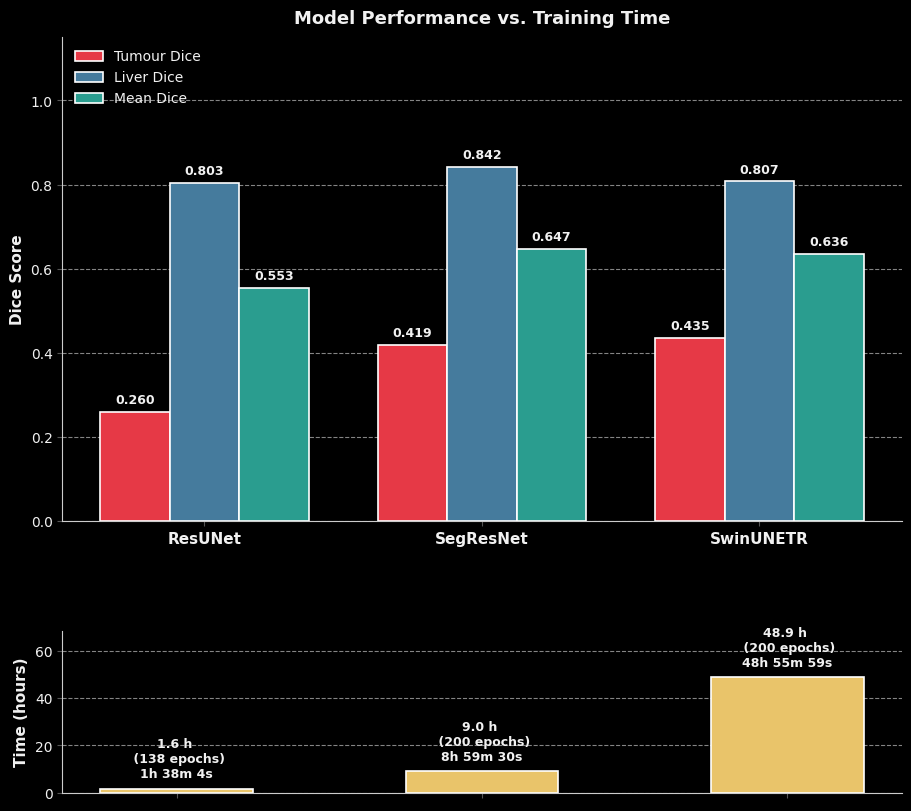

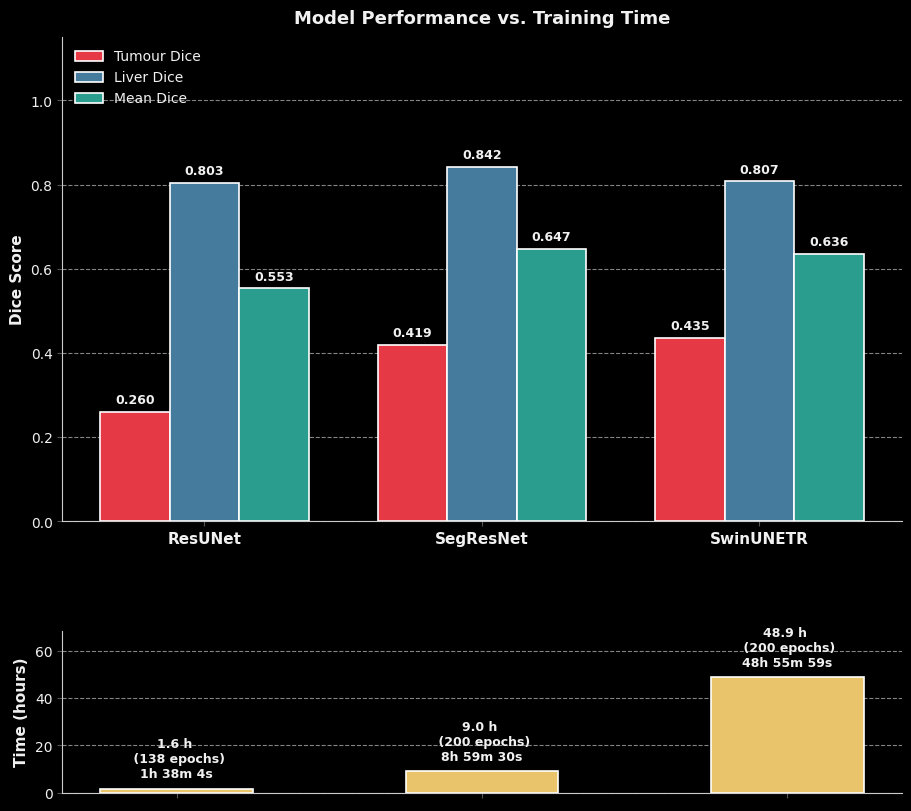

In [81]:
plot_results(post_strat)

## Test set

In [133]:
raw_resunet_test = pd.read_csv('../files/server_logs/2.4-20260606_UNET/validate/raw/reports/test_evaluation_results.csv')
raw_segresnet_test = pd.read_csv('../files/server_logs/2.4.1-20260607_SEGRESNET/validate/raw/reports/test_evaluation_results.csv')
raw_swinunetr_test = pd.read_csv('../files/server_logs/2.4.4-20260617_SWINUNETR/validate/raw/reports/test_evaluation_results.csv')

# post_resunet_test is missing
post_segresnet_test = pd.read_csv('../files/server_logs/2.4.1-20260607_SEGRESNET/validate/post/reports/test_evaluation_results.csv')
post_swinunetr_test = pd.read_csv('../files/server_logs/2.4.4-20260617_SWINUNETR/validate/post/reports/test_evaluation_results.csv')

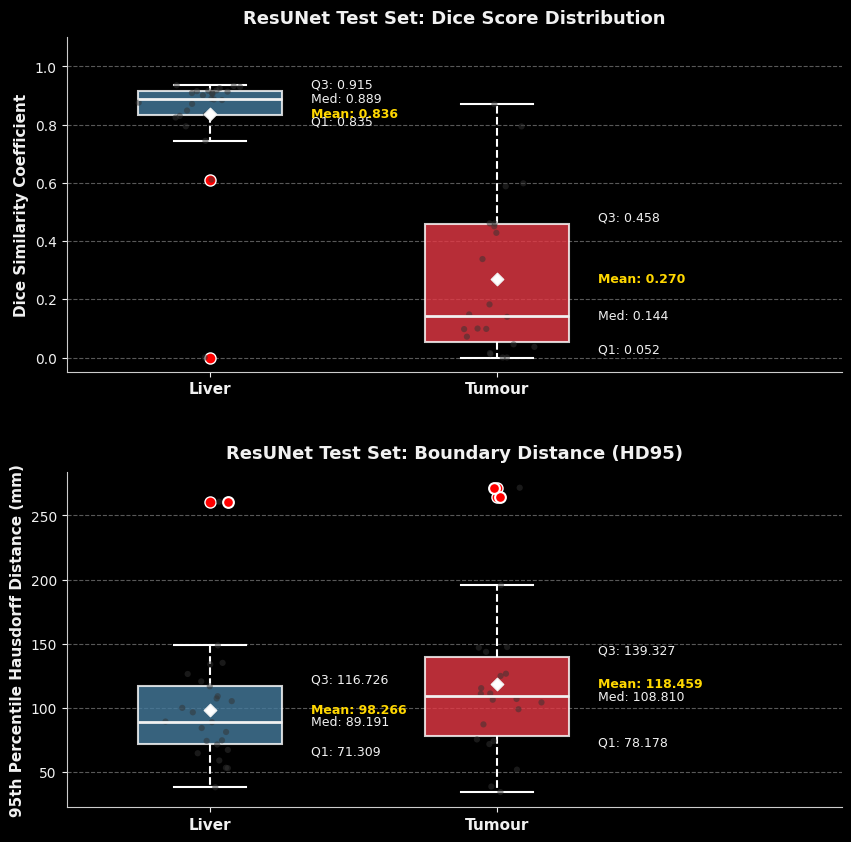

In [134]:
fig = plot_test_boxplots(raw_resunet_test, model_name="ResUNet")

In [138]:
# Missing
# fig = plot_test_boxplots(post_resunet_test, model_name="ResUNet (post)")

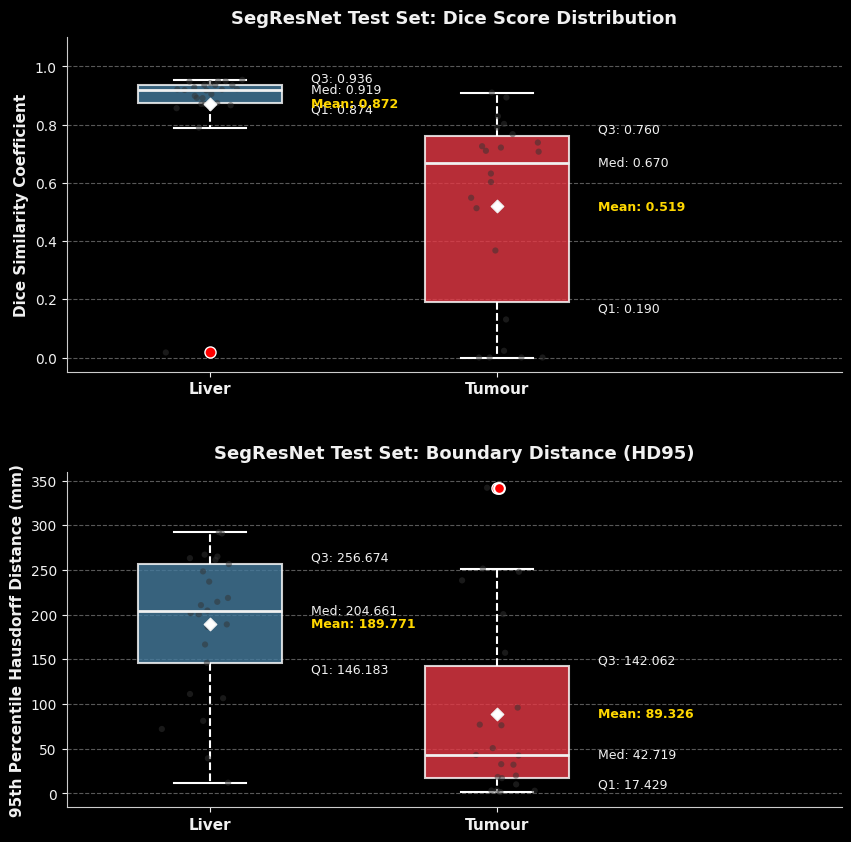

In [139]:
fig = plot_test_boxplots(raw_segresnet_test, model_name="SegResNet")

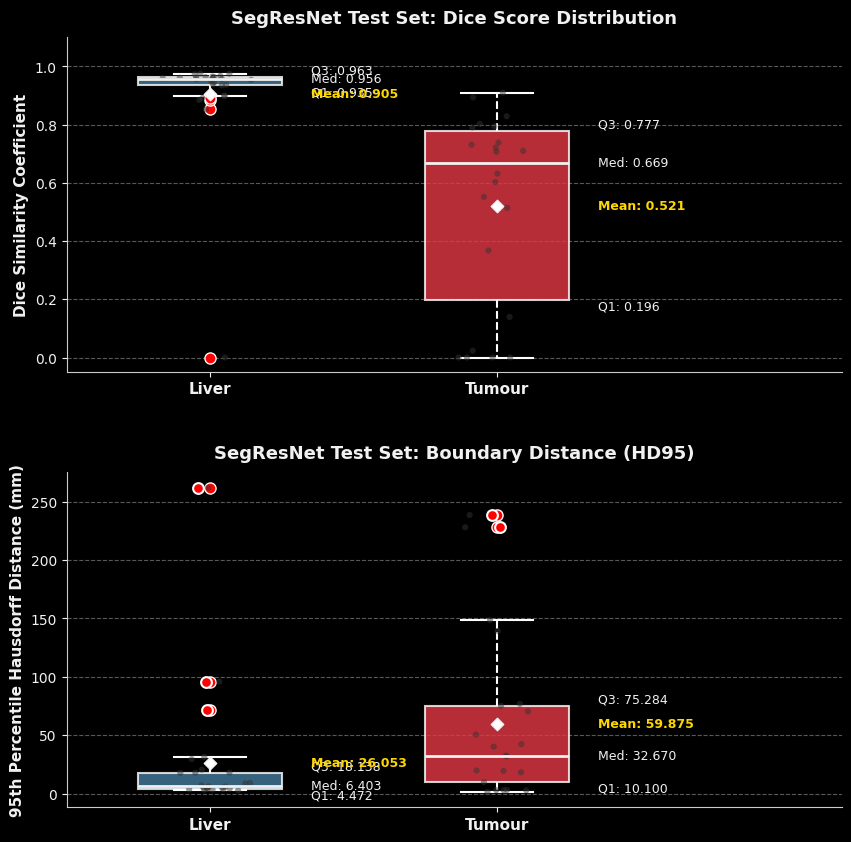

In [140]:
fig = plot_test_boxplots(post_segresnet_test, model_name="SegResNet")